# Fine-tune PP-OCRv6 cho OCR Truyện tranh (Manhwa/Webtoon)
Notebook này hướng dẫn quy trình fine-tune mô hình **PP-OCRv6** để nhận diện văn bản trong truyện tranh, tối ưu cho các font chữ đặc thù và cấu trúc bong bóng thoại.

In [3]:
!nvidia-smi
!nvcc --version

Thu Jul  2 12:10:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Cài đặt Môi trường & CUDA 12.6
Bước này thực hiện cài đặt bộ toolkit CUDA cần cho nền tảng Paddle và các thư viện hỗ trợ tính toán GPU để đảm bảo hiệu suất tốt nhất khi huấn luyện mô hình.

In [4]:
import os
# Download CUDA 12.6.0
!wget https://developer.download.nvidia.com/compute/cuda/12.6.0/local_installers/cuda-repo-ubuntu2204-12-6-local_12.6.0-560.28.03-1_amd64.deb
!dpkg -i cuda-repo-ubuntu2204-12-6-local_12.6.0-560.28.03-1_amd64.deb
!cp /var/cuda-repo-ubuntu2204-12-6-local/cuda-*-keyring.gpg /usr/share/keyrings/
!apt-get update
!apt-get -y install cuda-toolkit-12-6

--2026-07-02 12:10:34--  https://developer.download.nvidia.com/compute/cuda/12.6.0/local_installers/cuda-repo-ubuntu2204-12-6-local_12.6.0-560.28.03-1_amd64.deb
Resolving developer.download.nvidia.com (developer.download.nvidia.com)... 23.213.43.199, 23.213.43.207
Connecting to developer.download.nvidia.com (developer.download.nvidia.com)|23.213.43.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3355715790 (3.1G) [application/x-deb]
Saving to: ‘cuda-repo-ubuntu2204-12-6-local_12.6.0-560.28.03-1_amd64.deb’

cuda-repo-ubuntu220 100%[===================>]   3.12G  1.85MB/s    in 24m 34s 

2026-07-02 12:35:10 (2.17 MB/s) - ‘cuda-repo-ubuntu2204-12-6-local_12.6.0-560.28.03-1_amd64.deb’ saved [3355715790/3355715790]

Selecting previously unselected package cuda-repo-ubuntu2204-12-6-local.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack cuda-repo-ubuntu2204-12-6-local_12.6.0-560.28.03-1_amd64.deb ...
Unpacking cuda-rep

In [5]:
import os
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.6'
os.environ['PATH'] = '/usr/local/cuda-12.6/bin:' + os.environ['PATH']
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda-12.6/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

# Verify the installation
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Tue_Oct_29_23:50:19_PDT_2024
Cuda compilation tools, release 12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0


In [6]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 60.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 57.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 76.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 229.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 54.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 252.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [7]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version used by PyTorch: {torch.version.cuda}")
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.1+cu126
CUDA available: True
CUDA version used by PyTorch: 12.6
Current GPU: Tesla T4


## 2. Cài đặt PaddlePaddle & PaddleOCR
Cài đặt framework PaddlePaddle phiên bản hỗ trợ CUDA 12.6 và clone mã nguồn PaddleOCR để sử dụng các script huấn luyện chuẩn.

In [8]:
!pip install -q paddlepaddle-gpu==3.1.1 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!pip install -q lmdb rapidfuzz paddleocr visualdl paddle2onnx==2.1.0 "paddlex[ocr]==3.7.2" onnx==1.17.0

!pip install -q --force-reinstall nvidia-cudnn-cu12==9.10.2.21 nvidia-cusparselt-cu12==0.7.1 nvidia-nccl-cu12==2.29.3

!ldconfig /usr/local/cuda-12.6/lib64

import paddle
paddle.utils.run_check()
import torch
print(f"Paddle GPU: {paddle.device.is_compiled_with_cuda()}")
print(f"Torch version: {torch.__version__}")
print(f"Torch GPU: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 GB 502.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.4/201.4 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 21.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.12.1+cu126 requires nvidia-cudnn-cu12==9.10.2.21; platform_system == "Linux", but you have nvidia-cudnn-cu12 9.5.1.17 which is incompatible.
torch 2.12.1+cu126 requires nvidia-cusparselt-cu12==0.7.1; platform_system == "Linux", but you have nvidia-cuspar

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Running verify PaddlePaddle program ... 
PaddlePaddle works well on 1 GPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.
Paddle GPU: True
Torch version: 2.12.1+cu126
Torch GPU: True


## 3. Chuẩn bị Dữ liệu (Dataset)
Tải và giải nén bộ dữ liệu Manhwa đã được gán nhãn. Dữ liệu bao gồm phần Detection (xác định vùng chứa chữ) và Recognition (nhận diện nội dung chữ).

In [9]:
!wget https://github.com/tozydev/skanlator/releases/download/x-data/dataset.tar.gz
!tar -xzf dataset.tar.gz
!rm dataset.tar.gz

--2026-07-02 12:59:42--  https://github.com/tozydev/skanlator/releases/download/x-data/dataset.tar.gz
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1282643187/9d813b30-85bb-425d-9f8e-a8af6eac447e?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-07-02T14%3A00%3A24Z&rscd=attachment%3B+filename%3Ddataset.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-07-02T12%3A59%3A27Z&ske=2026-07-02T14%3A00%3A24Z&sks=b&skv=2018-11-09&sig=Il8ohU8%2Fb8tiLPg7jQqiWsGb75Dxyp1sH3x2qjmFFSs%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MzAwMDc4MiwibmJmIjoxNzgyOTk3MTgyLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5

In [10]:
import os

def count_images(path):
    if not os.path.exists(path):
        return 0
    return len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

def count_lines(file_path):
    if not os.path.exists(file_path):
        return 0
    with open(file_path, 'r') as f:
        return sum(1 for line in f)

det_all_img_path = 'dataset/det/img'
rec_train_path = 'dataset/rec/crop_img'

det_train_label = 'dataset/det/train.txt'
det_val_label = 'dataset/det/val.txt'
rec_train_label = 'dataset/rec/train.txt'
rec_val_label = 'dataset/rec/val.txt'

print(f"--- Thống kê số lượng file ảnh ---")
print(f"Tổng số ảnh trong DET (img): {count_images(det_all_img_path)}")
print(f"Số lượng ảnh đã cắt trong REC (crop_img): {count_images(rec_train_path)}")

print(f"\n--- Thống kê số lượng mẫu (dòng trong file label) ---")
print(f"DET Train: {count_lines(det_train_label)}")
print(f"DET Val  : {count_lines(det_val_label)}")
print(f"REC Train: {count_lines(rec_train_label)}")
print(f"REC Val  : {count_lines(rec_val_label)}")

--- Thống kê số lượng file ảnh ---
Tổng số ảnh trong DET (img): 1072
Số lượng ảnh đã cắt trong REC (crop_img): 6948

--- Thống kê số lượng mẫu (dòng trong file label) ---
DET Train: 906
DET Val  : 161
REC Train: 5873
REC Val  : 1075


In [11]:
print("--- 5 dòng đầu của det/train.txt ---")
!head -n 5 dataset/det/train.txt

print("\n--- 5 dòng đầu của rec/train.txt ---")
!head -n 5 dataset/rec/train.txt

--- 5 dòng đầu của det/train.txt ---
img/train_1.jpg	[{"transcription": "THE OCEAN IS", "points": [[55, 983], [171, 983], [171, 1002], [55, 1002]], "difficult": false}, {"transcription": "VAST.", "points": [[88, 1003], [139, 1003], [139, 1022], [88, 1022]], "difficult": false}, {"transcription": "LET US MAKE MORE", "points": [[306, 575], [630, 575], [630, 608], [306, 608]], "difficult": false}, {"transcription": "MEMORIES.", "points": [[372, 610], [564, 610], [564, 642], [372, 642]], "difficult": false}, {"transcription": "YOU DESERVE IT.", "points": [[186, 364], [347, 364], [347, 385], [186, 385]], "difficult": false}, {"transcription": "SIGN THIS PAPER.", "points": [[42, 1248], [248, 1248], [248, 1275], [42, 1275]], "difficult": false}, {"transcription": "HOW ABOUT RARE MAGIC?", "points": [[449, 184], [682, 184], [682, 202], [449, 202]], "difficult": false}]
img/train_2.jpg	[{"transcription": "TAKE THIS!", "points": [[117, 1095], [241, 1095], [241, 1117], [117, 1117]], "difficult": f

## 4. Tải Mô hình Pretrained
Chúng ta bắt đầu từ các trọng số đã được huấn luyện sẵn của PP-OCRv6 để tiết kiệm thời gian và tăng độ chính xác.

In [12]:
!mkdir -p pretrained

!wget -P pretrained https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv6_small_det_pretrained.pdparams
!wget -P pretrained https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv6_small_rec_pretrained.pdparams

!ls -lh pretrained

--2026-07-02 13:02:05--  https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv6_small_det_pretrained.pdparams
Resolving paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)... 103.235.47.176, 2402:2b40:7000:913:0:ff:b0a4:a156
Connecting to paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)|103.235.47.176|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10757224 (10M) [application/octet-stream]
Saving to: ‘pretrained/PP-OCRv6_small_det_pretrained.pdparams’

PP-OCRv6_small_det_ 100%[===================>]  10.26M  9.34MB/s    in 1.1s    

2026-07-02 13:02:07 (9.34 MB/s) - ‘pretrained/PP-OCRv6_small_det_pretrained.pdparams’ saved [10757224/10757224]

--2026-07-02 13:02:07--  https://paddle-model-ecology.bj.bcebos.com/paddlex/official_pretrained_model/PP-OCRv6_small_rec_pretrained.pdparams
Resolving paddle-model-ecology.bj.bcebos.com (paddle-model-ecology.bj.bcebos.com)... 103.235.47.176, 2402:2b

In [13]:
%cd /content
!git clone --depth 1 https://github.com/PaddlePaddle/PaddleOCR.git

/content
Cloning into 'PaddleOCR'...
remote: Enumerating objects: 2910, done.
remote: Counting objects: 100% (2910/2910), done.
remote: Compressing objects: 100% (2078/2078), done.
remote: Total 2910 (delta 783), reused 2579 (delta 739), pack-reused 0 (from 0)
Receiving objects: 100% (2910/2910), 96.56 MiB | 17.49 MiB/s, done.
Resolving deltas: 100% (783/783), done.


## 5. Cấu hình & Huấn luyện (Fine-tuning)
Thiết lập các tham số như số lượng epoch, step và đường dẫn lưu mô hình. Sau đó chạy script `train.py` cho cả hai thành phần Det và Rec.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 5.1. Thiết lập Cấu hình (Configuration)
Chúng ta định nghĩa các tham số quan trọng trong `config_dict` để ghi đè lên file `.yml` mặc định:
- **Global**: Lưu trữ đường dẫn mô hình pretrained, số lượng epoch (vòng lặp) và thư mục lưu kết quả.
- **Train/Eval**: Chỉ định đường dẫn tới tập dữ liệu ảnh và file nhãn (label) tương ứng.

In [14]:
det_onnx_model_dir = "output/PP-OCRv6_small_det_onnx"
rec_onnx_model_dir = "output/PP-OCRv6_small_rec_onnx"

det_best_model_path = "output/PP-OCRv6_small_det/best_model/model"
rec_best_model_path = "output/PP-OCRv6_small_rec/best_model/model"

det_infer_model_dir = "output/PP-OCRv6_small_det_infer"
rec_infer_model_dir = "output/PP-OCRv6_small_rec_infer"

det_train_config = {
    "Global": {
        "save_model_dir": "output/PP-OCRv6_small_det/",
        "pretrained_model": "pretrained/PP-OCRv6_small_det_pretrained",
        "epoch_num": 40,
        "save_epoch_step": 10,
        "eval_batch_step": [0, 226],
        "use_visualdl": True
    },
    "Train": {
        "dataset": {
            "data_dir": "dataset/det/",
            "label_file_list": ["dataset/det/train.txt"]
        },
    },
    "Eval": {
        "dataset": {
            "data_dir": "dataset/det/",
            "label_file_list": ["dataset/det/val.txt"]
        },
    }
}

det_val_config = {
    "Global": {
        "pretrained_model": det_best_model_path,
    },
}

det_export_config = {
     "Global": {
         "pretrained_model": det_best_model_path,
         "save_inference_dir": det_infer_model_dir,
     },
 }

rec_train_config = {
    "Global": {
        "save_model_dir": "output/PP-OCRv6_small_rec/",
        "pretrained_model": "pretrained/PP-OCRv6_small_rec_pretrained",
        "epoch_num": 20,
        "save_epoch_step": 5,
        "eval_batch_step": [0, 92],
        "use_visualdl": True,
        "character_dict_path": "PaddleOCR/ppocr/utils/dict/ppocrv6_dict.txt",
    },
    "Train": {
        "dataset": {
            "data_dir": "dataset/rec/",
            "label_file_list": ["dataset/rec/train.txt"]
        },
    },
    "Eval": {
        "dataset": {
            "data_dir": "dataset/rec/",
            "label_file_list": ["dataset/rec/val.txt"]
        },
    }
}

rec_val_config = {
     "Global": {
        "pretrained_model": rec_best_model_path,
    },
}

rec_export_config = {
    "Global": {
        "pretrained_model": rec_best_model_path,
        "save_inference_dir": rec_infer_model_dir,
    },
 }


In [15]:
import yaml
import copy

def dict_to_args(config_dict, prefix=""):
    args = []
    for k, v in config_dict.items():
        new_key = f"{prefix}.{k}" if prefix else k
        if isinstance(v, dict):
            args.extend(dict_to_args(v, new_key))
        else:
            if v is True: val_str = "True"
            elif v is False: val_str = "False"
            elif v is None: val_str = "null"
            elif isinstance(v, list):
                items = []
                for item in v:
                    items.append(str(item))
                list_content = f"[{','.join(items)}]"
                val_str = f"'{list_content}'"
            else:
                val_str = str(v)

            args.append(f"{new_key}={val_str}")
    return args

def merge_config(base_config, override_config):
    result = copy.deepcopy(base_config)
    for key, value in override_config.items():
        if key in result and isinstance(result[key], dict) and isinstance(value, dict):
            result[key] = merge_config(result[key], value)
        else:
            result[key] = copy.deepcopy(value)
    return result

det_train_args = " ".join(dict_to_args(det_train_config))
rec_train_args = " ".join(dict_to_args(rec_train_config))

det_val_args = " ".join(dict_to_args(merge_config(det_train_config, det_val_config)))
rec_val_args = " ".join(dict_to_args(merge_config(rec_train_config, rec_val_config)))

det_export_args = " ".join(dict_to_args(merge_config(det_train_config, det_export_config)))
rec_export_args = " ".join(dict_to_args(merge_config(rec_train_config, rec_export_config)))

### 5.2. Chạy Huấn luyện (Fine-tuning Execution)
Sử dụng script `tools/train.py` của PaddleOCR. Tham số `-c` chỉ định file cấu hình gốc của PP-OCRv6, và `-o` dùng để nạp các tùy chỉnh chúng ta vừa thiết lập ở bước trên.

In [16]:
!python3 PaddleOCR/tools/train.py -c PaddleOCR/configs/det/PP-OCRv6/PP-OCRv6_small_det.yml -o {det_train_args}

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/07/02 13:03:04] ppocr WARNING: You are using VisualDL, the VisualDL is deprecated and removed in ppocr!
[2026/07/02 13:03:04] ppocr INFO: Architecture : 
[2026/07/02 13:03:04] ppocr INFO:     Backbone : 
[2026/07/02 13:03:04] ppocr INFO:         det : True
[2026/07/02 13:03:04] ppocr INFO:         model_size : small
[2026/07/02 13:03:04] ppocr INFO:         name : PPLCNetV4
[2026/07/02 13:03:04] ppocr INFO:     Head : 
[2026/07/02 13:03:04] ppocr INFO:         aux_in_channels : 96
[2026/07/02 13:03:04] ppocr INFO:         fix_nan : True
[2026/07/02 13:03:04] ppocr INFO:         k : 50
[2026/07/02 13:03:04] ppocr INFO:    

In [17]:
!python3 PaddleOCR/tools/train.py -c PaddleOCR/configs/rec/PP-OCRv6/PP-OCRv6_small_rec.yml -o {rec_train_args}

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/07/02 14:20:20] ppocr WARNING: You are using VisualDL, the VisualDL is deprecated and removed in ppocr!
[2026/07/02 14:20:20] ppocr INFO: Architecture : 
[2026/07/02 14:20:20] ppocr INFO:     Backbone : 
[2026/07/02 14:20:20] ppocr INFO:         model_size : small
[2026/07/02 14:20:20] ppocr INFO:         name : PPLCNetV4
[2026/07/02 14:20:20] ppocr INFO:     Head : 
[2026/07/02 14:20:20] ppocr INFO:         head_list : 
[2026/07/02 14:20:20] ppocr INFO:             CTCHead : 
[2026/07/02 14:20:20] ppocr INFO:                 Head : 
[2026/07/02 14:20:20] ppocr INFO:                     fc_decay : 1e-05
[2026/07/02 14:20:

### 5.3. Đánh giá Mô hình (Evaluation)
Sau khi huấn luyện, chúng ta chạy script `tools/eval.py` trên tập **Validation** để kiểm tra các chỉ số như Precision, Recall và Hmean. Điều này giúp đảm bảo mô hình không bị quá khớp (overfitting).

In [18]:
!python3 PaddleOCR/tools/eval.py -c PaddleOCR/configs/det/PP-OCRv6/PP-OCRv6_small_det.yml -o {det_val_args}

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/07/02 14:48:04] ppocr WARNING: You are using VisualDL, the VisualDL is deprecated and removed in ppocr!
[2026/07/02 14:48:04] ppocr INFO: Architecture : 
[2026/07/02 14:48:04] ppocr INFO:     Backbone : 
[2026/07/02 14:48:04] ppocr INFO:         det : True
[2026/07/02 14:48:04] ppocr INFO:         model_size : small
[2026/07/02 14:48:04] ppocr INFO:         name : PPLCNetV4
[2026/07/02 14:48:04] ppocr INFO:     Head : 
[2026/07/02 14:48:04] ppocr INFO:         aux_in_channels : 96
[2026/07/02 14:48:04] ppocr INFO:         fix_nan : True
[2026/07/02 14:48:04] ppocr INFO:         k : 50
[2026/07/02 14:48:04] ppocr INFO:    

In [19]:
!python3 PaddleOCR/tools/eval.py -c PaddleOCR/configs/rec/PP-OCRv6/PP-OCRv6_small_rec.yml -o {rec_val_args}

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
[2026/07/02 14:48:32] ppocr WARNING: You are using VisualDL, the VisualDL is deprecated and removed in ppocr!
[2026/07/02 14:48:32] ppocr INFO: Architecture : 
[2026/07/02 14:48:32] ppocr INFO:     Backbone : 
[2026/07/02 14:48:32] ppocr INFO:         model_size : small
[2026/07/02 14:48:32] ppocr INFO:         name : PPLCNetV4
[2026/07/02 14:48:32] ppocr INFO:     Head : 
[2026/07/02 14:48:32] ppocr INFO:         head_list : 
[2026/07/02 14:48:32] ppocr INFO:             CTCHead : 
[2026/07/02 14:48:32] ppocr INFO:                 Head : 
[2026/07/02 14:48:32] ppocr INFO:                     fc_decay : 1e-05
[2026/07/02 14:48:

### 5.4. Xuất Mô hình Inference (Export)
Mô hình sau huấn luyện cần được chuyển đổi sang định dạng **Inference** (sử dụng `tools/export_model.py`) để loại bỏ các tham số thừa của quá trình training, giúp tăng tốc độ dự đoán khi triển khai thực tế.

In [20]:
!python3 PaddleOCR/tools/export_model.py -c PaddleOCR/configs/det/PP-OCRv6/PP-OCRv6_small_det.yml -o {det_export_args}

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
W0702 14:48:50.657944 47961 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 12.6
[2026/07/02 14:48:50] ppocr INFO: load pretrain successful from output/PP-OCRv6_small_det/best_model/model
[2026/07/02 14:48:50] ppocr INFO: Export inference config file to output/PP-OCRv6_small_det_infer/inference.yml
Skipping import of the encryption module
[2026/07/02 14:48:53] ppocr INFO: inference model is saved to output/PP-OCRv6_small_det_infer/inference


In [21]:
!python3 PaddleOCR/tools/export_model.py -c PaddleOCR/configs/rec/PP-OCRv6/PP-OCRv6_small_rec.yml -o {rec_export_args}

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Skipping import of the encryption module.
W0702 14:49:05.095378 48029 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 12.6
[2026/07/02 14:49:05] ppocr INFO: load pretrain successful from output/PP-OCRv6_small_rec/best_model/model
[2026/07/02 14:49:06] ppocr INFO: Export inference config file to output/PP-OCRv6_small_rec_infer/inference.yml
Skipping import of the encryption module
[2026/07/02 14:49:08] ppocr INFO: inference model is saved to output/PP-OCRv6_small_rec_infer/inference


Creating model: ('PP-OCRv6_small_det', 'output/PP-OCRv6_small_det_infer/', 'paddle')
Creating model: ('PP-OCRv6_small_rec', 'output/PP-OCRv6_small_rec_infer/', 'paddle')
Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/PaddleX3.0/fonts/simfang.ttf ...
[==================================================] 100.00%


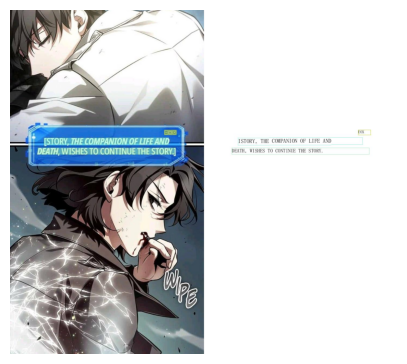

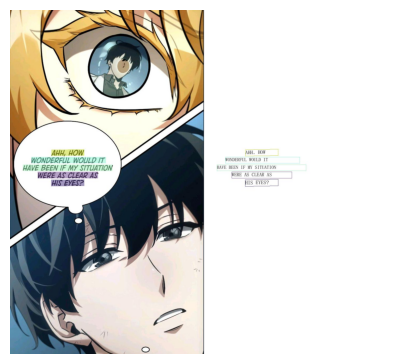

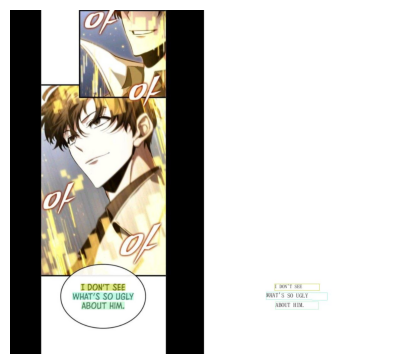

In [22]:
import requests
import os
import sys
from PIL import Image
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

urls = [
    "https://i.pinimg.com/736x/0d/af/b1/0dafb13a4db478a137573cace6b8c7f7.jpg",
    "https://i.pinimg.com/736x/ca/ec/ef/caecefb05e537e99108d2a04a8c46d3f.jpg",
    "https://i.pinimg.com/736x/ed/2f/73/ed2f738841d05fb2cdf35386a15143cb.jpg"
]

os.makedirs('test_images', exist_ok=True)
os.makedirs('output', exist_ok=True)
image_paths = []

for i, url in enumerate(urls):
    img_path = f'test_images/test_{i}.jpg'
    try:
        response = requests.get(url, timeout=15)
        if response.status_code == 200:
            with open(img_path, 'wb') as f:
                f.write(response.content)
            image_paths.append(img_path)
    except Exception as e:
        print(f"Lỗi khi tải {url}: {e}")

ocr = PaddleOCR(
    text_detection_model_name='PP-OCRv6_small_det',
    text_detection_model_dir='output/PP-OCRv6_small_det_infer/',
    text_recognition_model_name='PP-OCRv6_small_rec',
    text_recognition_model_dir='output/PP-OCRv6_small_rec_infer/',
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    engine="paddle",
)

for img_path in image_paths:
    results = ocr.predict(img_path)

    for res in results:
        res.save_to_img("output")
        res.save_to_json("output")

output_images = [f for f in os.listdir('output') if f.endswith(('.jpg', '.png')) and 'res' in f.lower()]
if not output_images:
    output_images = [f for f in os.listdir('output') if f.endswith(('.jpg', '.png'))]

for out_img in sorted(output_images):
    path = os.path.join('output', out_img)
    img = Image.open(path)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## 6. Chuyển đổi sang ONNX
Chuyển đổi mô hình sang định dạng ONNX để tối ưu tốc độ và hiệu năng khi chạy trên edge device.

In [23]:
!mkdir -p {det_onnx_model_dir}
!paddlex \
    --paddle2onnx \
    --paddle_model_dir {det_infer_model_dir} \
    --onnx_model_dir {det_onnx_model_dir} \
    --opset_version 11


Input dir: output/PP-OCRv6_small_det_infer
Output dir: output/PP-OCRv6_small_det_onnx
Paddle2ONNX conversion starting...
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
[Paddle2ONNX] Start parsing the Paddle model file...
[Paddle2ONNX] Use opset_version = 11 for ONNX export.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2026-07-02 14:50:02 [INFO]	Try to perform constant folding on the ONNX model with Polygraphy.
[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored
[I] Module: 'onnxruntime' is required, but not installed. Attempting to install now.
[I] Running installation command: /usr/bin/pyt

In [24]:
!mkdir -p {rec_onnx_model_dir}
!paddlex \
    --paddle2onnx \
    --paddle_model_dir {rec_infer_model_dir} \
    --onnx_model_dir {rec_onnx_model_dir} \
    --opset_version 11

Input dir: output/PP-OCRv6_small_rec_infer
Output dir: output/PP-OCRv6_small_rec_onnx
Paddle2ONNX conversion starting...
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:717: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
[Paddle2ONNX] Start parsing the Paddle model file...
[Paddle2ONNX] Use opset_version = 11 for ONNX export.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2026-07-02 14:51:12 [INFO]	Try to perform constant folding on the ONNX model with Polygraphy.
[W] 'colored' module is not installed, will not use colors when logging. To enable colors, please install the 'colored' module: python3 -m pip install colored
[I] Folding Constants | Pass 1
[I]     Total Nodes | Original:   979, After Folding:   480 |   499 Nodes Folded
[I] Folding Constan

## 7. Tải xuống kết quả huấn luyện

Tiến hành chạy lệnh nén các tệp đầu ra và tải về file `output.tar.gz`.


In [25]:
!tar -czvf output.tar.gz output/

output/
output/test_0_res.json
output/test_0_ocr_res_img.jpg
output/test_1_ocr_res_img.jpg
output/test_2_ocr_res_img.jpg
output/PP-OCRv6_small_det_infer/
output/PP-OCRv6_small_det_infer/inference.yml
output/PP-OCRv6_small_det_infer/inference.pdiparams
output/PP-OCRv6_small_det_infer/inference.json
output/PP-OCRv6_small_rec/
output/PP-OCRv6_small_rec/latest.pdopt
output/PP-OCRv6_small_rec/iter_epoch_10.pdparams
output/PP-OCRv6_small_rec/train.log
output/PP-OCRv6_small_rec/iter_epoch_5.pdopt
output/PP-OCRv6_small_rec/latest.pdparams
output/PP-OCRv6_small_rec/latest.states
output/PP-OCRv6_small_rec/iter_epoch_20.pdopt
output/PP-OCRv6_small_rec/best_model/
output/PP-OCRv6_small_rec/best_model/model.pdopt
output/PP-OCRv6_small_rec/best_model/model.pdparams
output/PP-OCRv6_small_rec/iter_epoch_15.pdparams
output/PP-OCRv6_small_rec/best_accuracy.states
output/PP-OCRv6_small_rec/iter_epoch_20.states
output/PP-OCRv6_small_rec/iter_epoch_15.states
output/PP-OCRv6_small_rec/iter_epoch_10.pdopt
ou

In [26]:
import os
path = 'output.tar.gz'
print(path, 'exists=', os.path.exists(path), 'size_MB=', round(os.path.getsize(path) / (1024*1024), 2) if os.path.exists(path) else None)

output.tar.gz exists= True size_MB= 2406.69
